# NSCLC における変異と薬剤感受性の探索解析

DepMap の mutation データと GDSC2 の drug response データを用いて、NSCLC cell line における EGFR / KRAS / TP53 変異と薬剤感受性の関連を探索する分析。

本解析は確証的な仮説検証ではなく、drug-gene pair の候補を探索的に抽出することを目的とした。

In [62]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/Lung_cancer/nsclc-mutation-drug-response-analysis/notebooks')

print(os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/Lung_cancer/nsclc-mutation-drug-response-analysis/notebooks


In [63]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

model = pd.read_csv('../data/raw/Model.csv')
gdsc = pd.read_excel('../data/raw/GDSC2_fitted_dose_response_27Oct23.xlsx')
mutation = pd.read_csv('../data/raw/OmicsSomaticMutations.csv')

/tmp/ipykernel_12527/1015031870.py:13: DtypeWarning: Columns (28,49,52,55,56,58,59,61) have mixed types. Specify dtype option on import or set low_memory=False.
  mutation = pd.read_csv('../data/raw/OmicsSomaticMutations.csv')


In [64]:
print(model.columns.to_list())
print(gdsc.columns.to_list())
print(mutation.columns.to_list())

['ModelID', 'PatientID', 'CellLineName', 'StrippedCellLineName', 'DepmapModelType', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'OncotreeCode', 'PatientSubtypeFeatures', 'RRID', 'Age', 'AgeCategory', 'Sex', 'PatientRace', 'PrimaryOrMetastasis', 'SampleCollectionSite', 'SourceType', 'SourceDetail', 'CatalogNumber', 'ModelType', 'TissueOrigin', 'ModelDerivationMaterial', 'ModelTreatment', 'PatientTreatmentStatus', 'PatientTreatmentType', 'PatientTreatmentDetails', 'Stage', 'StagingSystem', 'PatientTumorGrade', 'PatientTreatmentResponse', 'GrowthPattern', 'OnboardedMedia', 'FormulationID', 'SerumFreeMedia', 'PlateCoating', 'EngineeredModel', 'EngineeredModelDetails', 'CulturedResistanceDrug', 'PublicComments', 'CCLEName', 'HCMIID', 'PediatricModelType', 'ModelAvailableInDbgap', 'ModelSubtypeFeatures', 'WTSIMasterCellID', 'SangerModelID', 'COSMICID', 'ModelIDAlias']
['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'CANCER_TYPE', 'DRUG_

In [65]:
print('GDSC2 drugs:', gdsc['DRUG_NAME'].nunique())
print('GDSC2 cell lines:', gdsc['SANGER_MODEL_ID'].nunique())

GDSC2 drugs: 286
GDSC2 cell lines: 969


## 1. NSCLC cell line の抽出

DepMap の Model.csv から NSCLC（非小細胞肺がん）のみを抽出する。

GDSC との結合に SangerModelID を使うため、ID が欠損している cell line は除外する。

In [66]:
# check disease types in Lung lineage
lung_diseases = model[model['OncotreeLineage'] == 'Lung']['OncotreePrimaryDisease'].value_counts()
print(lung_diseases)

OncotreePrimaryDisease
Non-Small Cell Lung Cancer                  165
Lung Neuroendocrine Tumor                    86
Non-Cancerous                                 6
SMARCA4-deficient undifferentiated tumor      4
Name: count, dtype: int64


In [67]:
nsclc_meta = model[model['OncotreePrimaryDisease'] == 'Non-Small Cell Lung Cancer'].copy()

# drop rows without Sanger ID (cannot be merged with GDSC)
nsclc_meta = nsclc_meta[nsclc_meta['SangerModelID'].notna()].copy()

print('NSCLC with Sanger ID:', len(nsclc_meta))
nsclc_meta[['ModelID', 'StrippedCellLineName', 'SangerModelID', 'OncotreeSubtype']].head()

NSCLC with Sanger ID: 120


,ModelID,StrippedCellLineName,SangerModelID,OncotreeSubtype
10,ACH-000012,HCC827,SIDM01067,Lung Adenocarcinoma
13,ACH-000015,NCIH1581,SIDM00748,Large Cell Lung Carcinoma
19,ACH-000021,NCIH1693,SIDM00742,Lung Adenocarcinoma
28,ACH-000030,PC14,SIDM00237,Lung Adenocarcinoma
33,ACH-000035,NCIH1650,SIDM00745,Non-Small Cell Lung Cancer


## 2. Mutation matrix の作成
EGFR / KRAS / TP53 を対象遺伝子とする。EGFR と KRAS は NSCLC における代表的な driver gene であり、TP53は、比較的高頻度に変異が認められるがん抑制遺伝子である。

VepImpact が LOW の変異は影響が比較的小さい可能性があるため、除外した。
Cell line × Gene の binary matrix（1: mutant, 0: wild-type）を作成する。
本解析では変異数ではなく、各遺伝子に変異が存在するかどうかを扱う。

In [68]:
gene_need = ['EGFR', 'KRAS', 'TP53']

nsclc_model_id = nsclc_meta['ModelID'].tolist()

nsclc_mut = mutation[mutation['ModelID'].isin(nsclc_model_id)].copy()
nsclc_mut = nsclc_mut[nsclc_mut['HugoSymbol'].isin(gene_need)].copy()

print('mutation rows:', len(nsclc_mut))
print(nsclc_mut['HugoSymbol'].value_counts())
print(nsclc_mut['VepImpact'].value_counts())

mutation rows: 280
HugoSymbol
TP53    185
KRAS     58
EGFR     37
Name: count, dtype: int64
VepImpact
MODERATE    210
HIGH         65
LOW           5
Name: count, dtype: int64


In [69]:
# drop LOW impact (no protein change)
nsclc_mut = nsclc_mut[nsclc_mut['VepImpact'] != 'LOW'].copy()
print(nsclc_mut['VepImpact'].value_counts())

VepImpact
MODERATE    210
HIGH         65
Name: count, dtype: int64


In [70]:
# binary matrix: cell line x gene
mut_matrix = pd.crosstab(nsclc_mut['ModelID'], nsclc_mut['HugoSymbol'])
mut_matrix = (mut_matrix > 0).astype(int)

# include cell lines without any mutation as WT (0)
all_nsclc = pd.DataFrame(index=nsclc_model_id)
all_nsclc.index.name = 'ModelID'
mut_matrix = all_nsclc.join(mut_matrix, how='left').fillna(0).astype(int)

for gene in gene_need:
    if gene not in mut_matrix.columns:
        mut_matrix[gene] = 0

mut_matrix = mut_matrix[gene_need]

print('matrix shape:', mut_matrix.shape)
for gene in gene_need:
    n_mut = mut_matrix[gene].sum()
    n_wt = len(mut_matrix) - n_mut
    pct = n_mut / len(mut_matrix) * 100
    print(f'  {gene}: mut {n_mut} ({pct:.1f}%) / WT {n_wt}')

matrix shape: (120, 3)
  EGFR: mut 22 (18.3%) / WT 98
  KRAS: mut 33 (27.5%) / WT 87
  TP53: mut 96 (80.0%) / WT 24


## 3. GDSC2 との結合

DepMap と GDSC を SangerModelID 経由で結合する。Cell line 名による結合は表記揺れがあるため、ID ベースで行う方が確実。
- 同一 cell line で複数の測定値がある場合は平均を取る。

In [71]:
id_map = nsclc_meta[['SangerModelID', 'ModelID']].rename( columns={'SangerModelID': 'SANGER_MODEL_ID'})

gdsc_nsclc = pd.merge(
    gdsc,
    id_map,
    on='SANGER_MODEL_ID',
    how='inner'
)

gdsc_nsclc = (
    gdsc_nsclc
    .groupby(['DRUG_NAME', 'ModelID'], as_index=False)
    .agg(LN_IC50=('LN_IC50', 'mean'))
)

print('rows:', gdsc_nsclc.shape[0])
print('cell lines:', gdsc_nsclc['ModelID'].nunique())
print('drugs:', gdsc_nsclc['DRUG_NAME'].nunique())

rows: 26110
cell lines: 107
drugs: 286


## 4. 薬剤の選定

LN_IC50 のばらつきが小さい薬剤では mutation 群間の差を検出しにくいため、変動の大きい薬剤を候補とする。

条件は n_cell_lines >= 50 かつ std 上位 30 個。

In [72]:
drug_stats = gdsc_nsclc.groupby('DRUG_NAME').agg(
    n_cell_lines=('ModelID', 'nunique'),
    mean=('LN_IC50', 'mean'),
    median=('LN_IC50', 'median'),
    std=('LN_IC50', 'std'),
    q25=('LN_IC50', lambda x: x.quantile(0.25)),
    q75=('LN_IC50', lambda x: x.quantile(0.75)),
).reset_index()

drug_stats['IQR'] = drug_stats['q75'] - drug_stats['q25']

drug_stats = drug_stats[drug_stats['n_cell_lines'] >= 50].copy()
top_30_drugs = drug_stats.sort_values('std', ascending=False).head(30).reset_index(drop=True)

print(f'drugs with n>=50: {len(drug_stats)}')
top_30_drugs

drugs with n>=50: 270


,DRUG_NAME,n_cell_lines,mean,median,std,q25,q75,IQR
0,Gemcitabine,107,0.173112,0.013648,2.743412,-1.878521,2.460555,4.339076
1,AZD5582,99,2.276300,2.287761,2.407925,1.552919,3.396298,1.843379
2,Daporinad,64,-2.487576,-3.300136,2.400402,-3.966411,-1.588791,2.377621
3,Methotrexate,102,0.501396,0.826291,2.390344,-1.408655,2.595299,4.003954
4,Sapitinib,106,3.215794,3.946209,2.313249,1.905660,4.849433,2.943774
5,BI-2536,103,-0.495072,-0.646952,2.306110,-2.521357,1.276032,3.797388
6,Docetaxel,107,-3.056738,-3.443224,2.301533,-4.912272,-1.052177,3.860095
7,Vinblastine,81,-2.586639,-2.974955,2.290891,-4.374151,-1.314457,3.059694
8,BEN,79,4.384532,4.567884,2.232480,2.942870,6.451659,3.508789
9,Vinorelbine,107,-2.317363,-2.731434,2.162134,-3.975707,-0.794501,3.181205


## 5. 統計検定

LN_IC50 は正規分布に従うとは限らないため、変異群と野生型群の比較には、ノンパラメトリック検定である Mann-Whitney U test を用いた。

また、p-value だけでは差の大きさを評価しにくいため、効果量として Cliff's delta を算出した。Cliff's delta の大きさは、Romano et al. (2006) の基準に基づき、0.147、0.330、0.474 をそれぞれ small、medium、large の目安として解釈した。

なお、サンプル数が少ない場合は検定結果が不安定になりやすいため、本解析では変異群および野生型群がそれぞれ5例以上ある drug-gene pair のみを対象とした。

In [73]:
def cliffs_delta(x, y):
    x, y = np.array(x), np.array(y)
    nx, ny = len(x), len(y)
    greater = sum((xi > y).sum() for xi in x)
    less = sum((xi < y).sum() for xi in x)
    return (greater - less) / (nx * ny)


def effect_label(d):
    a = abs(d)
    if a < 0.147:
        return 'negligible'
    if a < 0.330:
        return 'small'
    if a < 0.474:
        return 'medium'
    return 'large'

In [74]:
def run_test(drug, gene, gdsc_nsclc, mut_matrix, col='LN_IC50'):
    df = gdsc_nsclc[gdsc_nsclc['DRUG_NAME'] == drug][['ModelID', col]].merge(
        mut_matrix[[gene]].reset_index(), on='ModelID', how='inner'
    ).dropna(subset=[col])

    mut = df[df[gene] == 1][col]
    wt = df[df[gene] == 0][col]

    # skip if either group is too small
    if len(mut) < 5 or len(wt) < 5:
        return None

    _, pval = stats.mannwhitneyu(mut, wt, alternative='two-sided')
    delta = cliffs_delta(mut, wt)

    return {
        'drug': drug,
        'gene': gene,
        'n_mutant': len(mut),
        'n_wildtype': len(wt),
        'n_total': len(mut) + len(wt),
        'mean_mutant': round(mut.mean(), 4),
        'mean_wildtype': round(wt.mean(), 4),
        'mean_diff': round(mut.mean() - wt.mean(), 4),
        'p_value': pval,
        'cliffs_delta': delta,
        'effect_size': effect_label(delta),
    }

In [75]:
# loop over (drug x gene) pairs
results = []
for drug in top_30_drugs['DRUG_NAME']:
    for gene in gene_need:
        r = run_test(drug, gene, gdsc_nsclc, mut_matrix)
        if r is not None:
            results.append(r)

results_df = pd.DataFrame(results)
print('tests:', len(results_df))
results_df.head()

tests: 90


,drug,gene,n_mutant,n_wildtype,n_total,mean_mutant,mean_wildtype,mean_diff,p_value,cliffs_delta,effect_size
0,Gemcitabine,EGFR,20,87,107,0.5078,0.0962,0.4116,0.464667,0.105747,negligible
1,Gemcitabine,KRAS,30,77,107,0.0823,0.2085,-0.1261,0.700299,-0.048485,negligible
2,Gemcitabine,TP53,87,20,107,0.3209,-0.4697,0.7906,0.221468,0.176437,small
3,AZD5582,EGFR,20,79,99,2.8010,2.1435,0.6575,0.124004,0.224051,small
4,AZD5582,KRAS,27,72,99,1.9756,2.3891,-0.4135,0.266253,-0.146091,negligible


## 6. 多重検定の補正（FDR）

本解析では、30薬剤 × 3遺伝子の最大90通りの drug-gene pair について検定を行う。そのため、多重検定による偽陽性を考慮し、Benjamini-Hochberg 法を用いて偽発見率（False Discovery Rate; FDR）を補正した。

一方で、候補探索を目的とする解析であるため、FDR補正後の有意性だけでなく、raw p-value、Cliff's delta、サンプル数も併せて確認した。

In [76]:
reject, p_adj, _, _ = multipletests(results_df['p_value'], alpha=0.05, method='fdr_bh')
results_df['p_adj'] = p_adj
results_df['significant_fdr'] = reject
results_df['abs_delta'] = results_df['cliffs_delta'].abs()

print(f"total: {len(results_df)}")
print(f"raw p<0.05: {(results_df['p_value'] < 0.05).sum()}")
print(f"FDR sig: {results_df['significant_fdr'].sum()}")

total: 90
raw p<0.05: 9
FDR sig: 0


In [77]:
# sort by effect size
show_cols = ['drug', 'gene', 'n_mutant', 'n_wildtype', 'mean_diff',
             'p_value', 'p_adj', 'cliffs_delta', 'effect_size']

results_df.sort_values('abs_delta', ascending=False)[show_cols].head(20)

,drug,gene,n_mutant,n_wildtype,mean_diff,p_value,p_adj,cliffs_delta,effect_size
68,IGF1R_3801,TP53,64,15,1.1961,0.011569,0.290040,0.421875,medium
67,IGF1R_3801,KRAS,21,58,-1.3010,0.016279,0.290040,-0.356322,medium
38,Trametinib,TP53,87,20,1.2035,0.014474,0.290040,0.352299,medium
58,Afatinib,KRAS,30,77,1.1995,0.009395,0.290040,0.324675,small
62,PD0325901,TP53,87,20,1.0713,0.029142,0.291418,0.314368,small
61,PD0325901,KRAS,30,77,-1.0209,0.013160,0.290040,-0.309957,small
55,Ibrutinib,KRAS,27,72,1.1481,0.022934,0.291418,0.298354,small
13,Sapitinib,KRAS,30,76,1.3412,0.019336,0.290040,0.292982,small
37,Trametinib,KRAS,30,77,-0.9136,0.027665,0.291418,-0.275325,small
33,AZD5991,EGFR,18,61,0.7320,0.080571,0.603218,0.273224,small


In [78]:
# exploratory candidates: raw p<0.05 & |delta|>=0.2
hits = results_df[
    (results_df['p_value'] < 0.05) & (results_df['abs_delta'] >= 0.2)
].sort_values('abs_delta', ascending=False)

print(f'candidates: {len(hits)}')
hits[show_cols]

candidates: 9


,drug,gene,n_mutant,n_wildtype,mean_diff,p_value,p_adj,cliffs_delta,effect_size
68,IGF1R_3801,TP53,64,15,1.1961,0.011569,0.290040,0.421875,medium
67,IGF1R_3801,KRAS,21,58,-1.3010,0.016279,0.290040,-0.356322,medium
38,Trametinib,TP53,87,20,1.2035,0.014474,0.290040,0.352299,medium
58,Afatinib,KRAS,30,77,1.1995,0.009395,0.290040,0.324675,small
62,PD0325901,TP53,87,20,1.0713,0.029142,0.291418,0.314368,small
61,PD0325901,KRAS,30,77,-1.0209,0.013160,0.290040,-0.309957,small
55,Ibrutinib,KRAS,27,72,1.1481,0.022934,0.291418,0.298354,small
13,Sapitinib,KRAS,30,76,1.3412,0.019336,0.290040,0.292982,small
37,Trametinib,KRAS,30,77,-0.9136,0.027665,0.291418,-0.275325,small


## 7. Focused analysis: KRAS × MEK阻害薬

Trametinib と PD0325901 は、いずれも MEK阻害薬である。本データでは、両薬剤において KRAS変異群の LN_IC50 が野生型群より低い傾向が見られた。

ただし、FDR補正後には有意ではなく、効果量も small にとどまった。そのため、本結果は確定的なバイオマーカーとしてではなく、探索的な観察結果として解釈した。

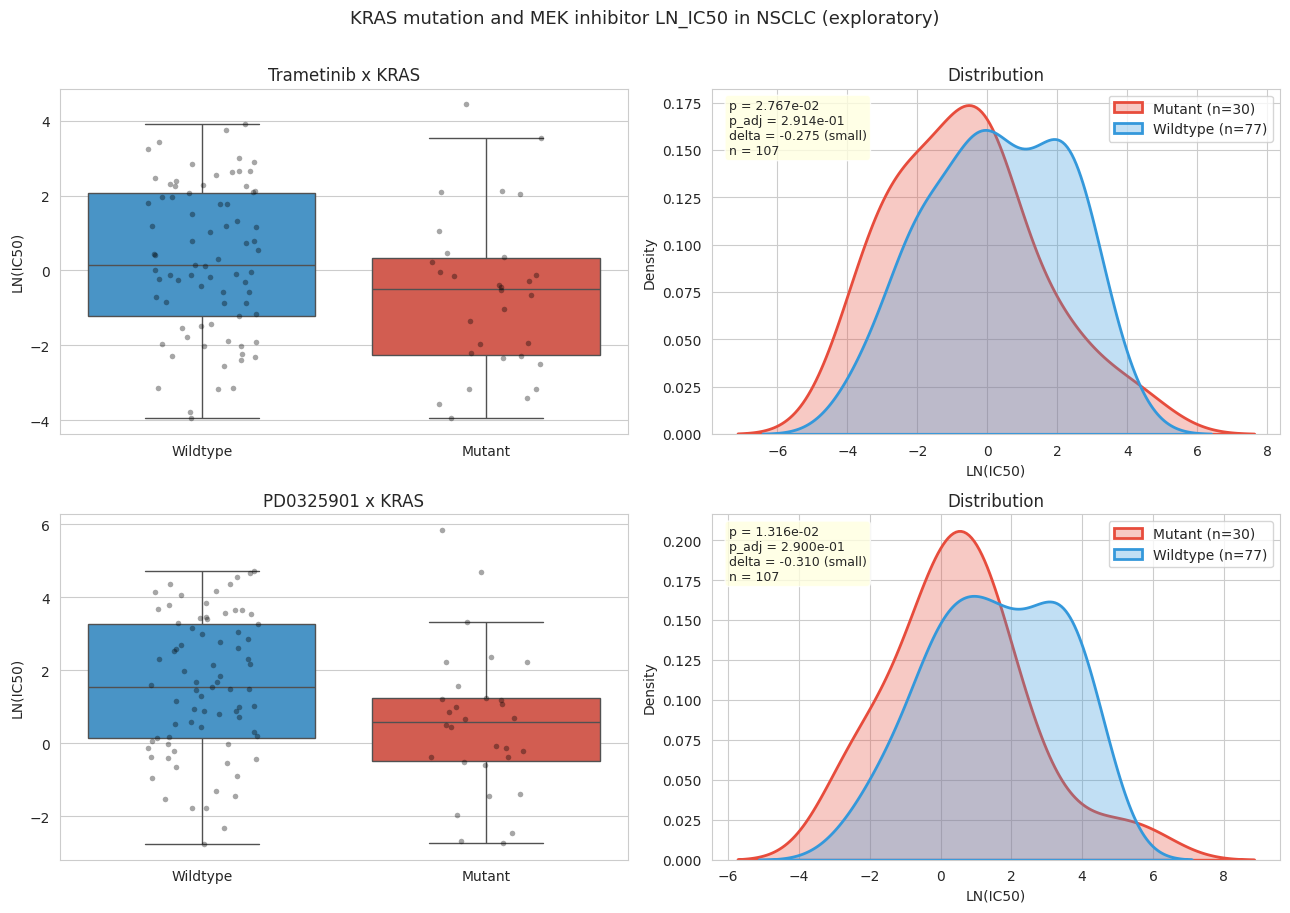

In [79]:
FOCUS_PAIRS = [('Trametinib', 'KRAS'), ('PD0325901', 'KRAS')]


def plot_pair(drug, gene, ax_box, ax_kde, col='LN_IC50'):
    row = results_df[(results_df['drug'] == drug) & (results_df['gene'] == gene)].iloc[0]

    df = gdsc_nsclc[gdsc_nsclc['DRUG_NAME'] == drug][['ModelID', col]].merge(
        mut_matrix[[gene]].reset_index(), on='ModelID'
    ).dropna(subset=[col])
    df['Group'] = df[gene].map({1: 'Mutant', 0: 'Wildtype'})

    palette = {'Mutant': '#e74c3c', 'Wildtype': '#3498db'}

    sns.boxplot(data=df, x='Group', y=col,hue='Group', palette=palette, showfliers=False, ax=ax_box)
    sns.stripplot(data=df, x='Group', y=col, color='black', alpha=0.35, size=4, jitter=0.2, ax=ax_box)
    ax_box.set_title(f'{drug} x {gene}')
    ax_box.set_ylabel('LN(IC50)')
    ax_box.set_xlabel('')

    for grp, color in palette.items():
        sub = df[df['Group'] == grp][col]
        sns.kdeplot(sub, ax=ax_kde, label=f'{grp} (n={len(sub)})',
                    color=color, fill=True, alpha=0.3, linewidth=2)

    txt = (f"p = {row['p_value']:.3e}\n"
           f"p_adj = {row['p_adj']:.3e}\n"
           f"delta = {row['cliffs_delta']:.3f} ({row['effect_size']})\n"
           f"n = {row['n_total']}")
    ax_kde.text(0.03, 0.97, txt, transform=ax_kde.transAxes, fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax_kde.set_title('Distribution')
    ax_kde.set_xlabel('LN(IC50)')
    ax_kde.legend()


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for i, (drug, gene) in enumerate(FOCUS_PAIRS):
    plot_pair(drug, gene, axes[i][0], axes[i][1])

fig.suptitle('KRAS mutation and MEK inhibitor LN_IC50 in NSCLC (exploratory)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [80]:
# summary table for focus pairs
summary_cols = ['drug', 'gene', 'n_mutant', 'n_wildtype', 'n_total',
                'mean_mutant', 'mean_wildtype', 'mean_diff',
                'p_value', 'p_adj', 'cliffs_delta', 'effect_size']

focus_summary = results_df[
    results_df.apply(lambda r: (r['drug'], r['gene']) in FOCUS_PAIRS, axis=1)
][summary_cols]

focus_summary

,drug,gene,n_mutant,n_wildtype,n_total,mean_mutant,mean_wildtype,mean_diff,p_value,p_adj,cliffs_delta,effect_size
37,Trametinib,KRAS,30,77,107,-0.6378,0.2758,-0.9136,0.027665,0.291418,-0.275325,small
61,PD0325901,KRAS,30,77,107,0.5415,1.5624,-1.0209,0.013160,0.290040,-0.309957,small


## 8. 処理済みデータの保存

ML notebook (02) で利用するため、前処理済みのデータと検定結果を pickle 形式で保存する。

In [81]:
import os
import pickle

os.makedirs('../data/results', exist_ok=True)


processed = {
    'mut_matrix': mut_matrix,
    'gdsc_nsclc': gdsc_nsclc,
    'nsclc_meta': nsclc_meta,
    'top_30_drugs': top_30_drugs,
    'results_df': results_df,
    'FOCUS_PAIRS': FOCUS_PAIRS,
    'gene_need': gene_need,
}

with open('../data/results/processed_data.pkl', 'wb') as f:
    pickle.dump(processed, f)

print('saved: ../data/results/processed_data.pkl')

saved: ../data/results/processed_data.pkl


## 限界点

- FDR 補正後に有意となった薬剤–遺伝子ペアは確認されなかった
- サンプルサイズが小さい (例: EGFR mutant n=22)
- 多重検定: 90 回の検定を行ったため raw p-value は探索的に解釈する必要がある
- Cell line データは in vitro であり、患者の反応とは異なる可能性
- Mutation のみを feature としており、expression / CNV / pathway activity は未反映
- TP53 の WT 群が小さく (n=20)、結果が不安定